# Predicting payment failures at a payment gateway

Abhay | dataset: `payments_ab_failure_200k.csv` (201,200 payment attempts)

PayFlow is a payment gateway. Merchants send us payment attempts, we route each one to a
bank, and roughly 16% of them fail. Each failure is a lost sale for the merchant.

Two questions here, and they need two different methods:

1. Did our new `smart_retry` policy actually work? (A/B test, section 4)
2. Can we predict which payment will fail? (classification, sections 5-7)

**Cost of getting it wrong.** Missing a failure means the merchant loses a sale, roughly
₹450. A false alarm means we reroute a payment that would have worked anyway, roughly ₹30.
So a miss costs about 15x more than a false alarm.

Two things follow from that. Accuracy is useless as a metric here (always guessing
"success" scores 84%), and 0.5 is almost certainly the wrong cutoff. I come back to the
cutoff in section 7.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
import xgboost as xgb

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e5e4e0",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8a85"

SEED = 42

In [2]:
df = pd.read_csv("payments_ab_failure_200k.csv")
print(df.shape)
df.head()

(201200, 35)


,txn_id,txn_timestamp,txn_hour,is_weekend,merchant_id,merchant_category,payment_method,card_network,issuer_bank_code,device_os,region,customer_tier,experiment_group,txn_amount_inr,customer_age,is_international,kyc_verified,card_bin_country_match,device_trust_score,merchant_tenure_months,merchant_avg_ticket_size_30d,merchant_gmv_per_txn_30d,merchant_success_rate_30d,merchant_risk_score,session_duration_sec,network_latency_ms,gateway_load_pct,prior_failed_attempts_24h,retry_attempt_number,data_version,gateway_error_code,retry_within_10min_flag,support_ticket_raised,payment_failed,revenue_loss_inr
0,TXN-00043235,2026-03-20 22:14:31,22,0,MID-0774,Travel,Debit Card,Mastercard,IBK017,iOS,West,New,control,5788.52,35.0,0,1,1,66.2,36,3142.42,3784.74,85.01,62.6,79.8,191.3,45.8,1,3,v2.1,NaN,0,0,0,0.0
1,TXN-00154565,2026-05-17 09:40:59,9,1,MID-0916,SaaS,UPI,Not Applicable,IBK023,Android,West,Loyal,control,263.56,37.0,0,0,1,61.1,100,523.10,640.32,84.31,35.4,144.5,264.4,62.1,1,3,v2.1,NaN,0,0,0,0.0
2,TXN-00130140,2026-04-29 12:47:58,12,0,MID-0270,Utilities,UPI,NOT APPLICABLE,IBK023,Web,East,Loyal,control,633.64,39.0,0,1,1,79.1,16,2024.77,2149.63,93.83,58.0,8.0,147.9,70.7,0,1,v2.1,NaN,0,0,0,0.0
3,TXN-00063616,2026-02-26 19:27:00,19,0,MID-0710,unknown,EMI,Visa,IBK009,Android,West,New,control,288.24,NaN,0,1,1,100.0,34,141.26,50.00,79.46,33.1,169.7,15204.5,86.6,0,1,v2.1,NaN,0,0,0,0.0
4,TXN-00080871,2026-02-16 11:39:50,11,0,MID-1090,Education,UPI,Not Applicable,IBK041,Web,West,New,smart_retry,511.30,NaN,0,1,1,94.4,13,739.62,780.85,91.91,58.7,8.0,357.4,70.4,0,1,v2.1,NaN,0,0,0,0.0


In [3]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 201200 entries, 0 to 201199
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   txn_id                        201200 non-null  str    
 1   txn_timestamp                 201200 non-null  str    
 2   txn_hour                      201200 non-null  int64  
 3   is_weekend                    201200 non-null  int64  
 4   merchant_id                   201200 non-null  str    
 5   merchant_category             201200 non-null  str    
 6   payment_method                201200 non-null  str    
 7   card_network                  201200 non-null  str    
 8   issuer_bank_code              201200 non-null  str    
 9   device_os                     201200 non-null  str    
 10  region                        201200 non-null  str    
 11  customer_tier                 201200 non-null  str    
 12  experiment_group              201200 non-null  str    


---
# 1. Cleaning

Five problems in this data. What matters isn't that I fixed them, it's that the fix is
different each time depending on what's actually wrong.


In [4]:
# The payment webhook fires twice sometimes, so the same payment gets written twice
print("duplicate txn_id:", df.duplicated(subset="txn_id").sum())
df = df.drop_duplicates(subset="txn_id").reset_index(drop=True)
print("rows now:", len(df))

duplicate txn_id: 1200


rows now: 200000


A duplicate is the same payment recorded twice, not two payments. If one copy lands in
train and the other in test, the model memorises it and then gets graded on it.


In [5]:
# A column with one value in it is doing nothing
print(df["data_version"].unique())
df = df.drop(columns=["data_version"])

<StringArray>
['v2.1']
Length: 1, dtype: str


In [6]:
# Card network is spelled several different ways
print("before:", df["card_network"].nunique(), "levels")
df["card_network"] = df["card_network"].str.strip().str.title()
df["merchant_id"] = df["merchant_id"].str.strip()
print("after :", df["card_network"].nunique(), "levels")
print(sorted(df["card_network"].unique()))

before: 20 levels
after : 5 levels
['Amex', 'Mastercard', 'Not Applicable', 'Rupay', 'Visa']


Skip this and `"Visa"`, `"VISA"` and `" Visa "` end up as three separate one-hot columns,
each holding a third of the Visa payments. Nothing errors. You just get three weak signals
instead of one good one, and you'd never know why the model underperformed.


In [7]:
print("ages of 0 or 999:", df["customer_age"].isin([0, 999]).sum())
print("negative amounts :", (df["txn_amount_inr"] < 0).sum())

# 0 and 999 are what the checkout app writes when it doesn't know the age
df.loc[df["customer_age"].isin([0, 999]), "customer_age"] = np.nan

# Negative amounts are refunds that got mixed into the payments table
df = df[df["txn_amount_inr"] > 0].reset_index(drop=True)
print("rows now:", len(df))

ages of 0 or 999: 1100
negative amounts : 650


rows now: 199350


These two look similar but they're not, and the difference decides the fix.

Age 999 is a fine row with one bad field. Blank it out, fill it in later, keep the other 30
columns. Leave it as 999 and the model thinks some customers are 999 years old.

A negative amount is a row that shouldn't be in this table at all. It's a refund, not a
payment attempt. There's nothing to fill in, so it goes.


In [8]:
df["txn_timestamp"] = pd.to_datetime(df["txn_timestamp"])
df["txn_month"] = df["txn_timestamp"].dt.month

missing = (df.isna().mean() * 100).round(2)
print(missing[missing > 0].sort_values(ascending=False).to_string())

gateway_error_code     82.28
customer_age           10.58
device_trust_score      6.98
merchant_risk_score     2.98


In [9]:
# Before picking how to fill these: does "missing" itself tell us anything?
for col in ["customer_age", "device_trust_score", "merchant_risk_score"]:
    rates = df.groupby(df[col].isna())["payment_failed"].mean()
    print(f"{col:22s} present {rates[False]:.4f}   missing {rates[True]:.4f}")

print(f"\noverall failure rate   {df['payment_failed'].mean():.4f}")

customer_age           present 0.1604   missing 0.1574
device_trust_score     present 0.1601   missing 0.1605
merchant_risk_score    present 0.1602   missing 0.1560

overall failure rate   0.1601


Same failure rate either way, so the gaps look like a logging glitch rather than a signal.
Median filling is fine and I don't need extra "was this missing" flag columns. If the rates
had come out different, say 16% vs 24%, the fact of it being missing would itself have been
worth a column.

The filling happens later, inside the pipeline. The median has to come from the training
data only. Compute it here, across the whole table, and the test set has already leaked in.


---
# 2. Exploring

## 2.1 Class balance


In [10]:
print(df["payment_failed"].value_counts().to_string())
print(f"\nfailure rate: {df['payment_failed'].mean():.1%}")
print(f"always guessing 'success' would score {1 - df['payment_failed'].mean():.1%} accuracy")

payment_failed
0    167434
1     31916

failure rate: 16.0%
always guessing 'success' would score 84.0% accuracy


16% is imbalanced but not extreme. Three consequences:

- Accuracy is out. It's reported nowhere below.
- I use ROC-AUC and PR-AUC. PR-AUC only looks at the failures, which is the class we care about.
- `class_weight="balanced"` stops the model just learning to say "success". At 16% that's
  enough. SMOTE and friends are for much rarer targets and I'd rather not invent rows.


## 2.2 Those latency outliers

count    199350.0
mean        862.0
std        3186.0
min          56.0
25%         196.0
50%         242.0
75%         305.0
max       24999.0


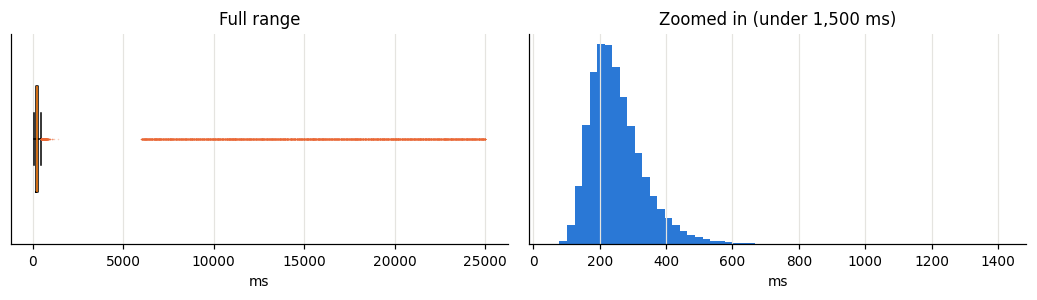

In [11]:
lat = df["network_latency_ms"]
print(lat.describe().round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.8))
axes[0].boxplot(lat, vert=False, widths=0.5,
                flierprops=dict(marker=".", markersize=2, markerfacecolor=ORANGE,
                                markeredgecolor="none", alpha=0.3))
axes[0].set_title("Full range"); axes[0].set_xlabel("ms"); axes[0].set_yticks([])
axes[1].hist(lat[lat < 1500], bins=60, color=BLUE)
axes[1].set_title("Zoomed in (under 1,500 ms)"); axes[1].set_xlabel("ms"); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

In [12]:
# My first instinct was to cut everything past the IQR fence. Checked first, and it's
# a good thing I did - the slow payments aren't all the same thing.
for low, high, label in [(0, 470, "normal"), (470, 5000, "slow"), (5000, 1e9, "impossible")]:
    rows = (lat > low) & (lat <= high)
    print(f"{label:12s} {rows.sum():7,} rows ({rows.mean():5.1%})   "
          f"failure rate {df.loc[rows, 'payment_failed'].mean():.3f}")

print(f"\noverall failure rate {df['payment_failed'].mean():.3f}")

normal       187,423 rows (94.0%)   failure rate 0.156
slow           3,974 rows ( 2.0%)   failure rate 0.334
impossible     7,953 rows ( 4.0%)   failure rate 0.167

overall failure rate 0.160


There are two different things hiding in that tail.

The 470-5,000ms group fails at 33%, double the base rate. That's real signal and I'd have
thrown it away if I'd trusted the boxplot.

Everything past 5,000ms fails at 17%, same as everyone else. A 25 second payment isn't
physically possible, so those are broken sensor readings, not slow payments.

So for logistic regression and KNN I cap latency at 3,000ms, which is the gateway's own
timeout. That flattens the junk without touching the genuinely slow ones. Tree models don't
need capping at all: a tree asks "is latency above 400?", and whether the answer is 6,000 or
25,000 doesn't change which side of the split you land on.


## 2.3 Correlations

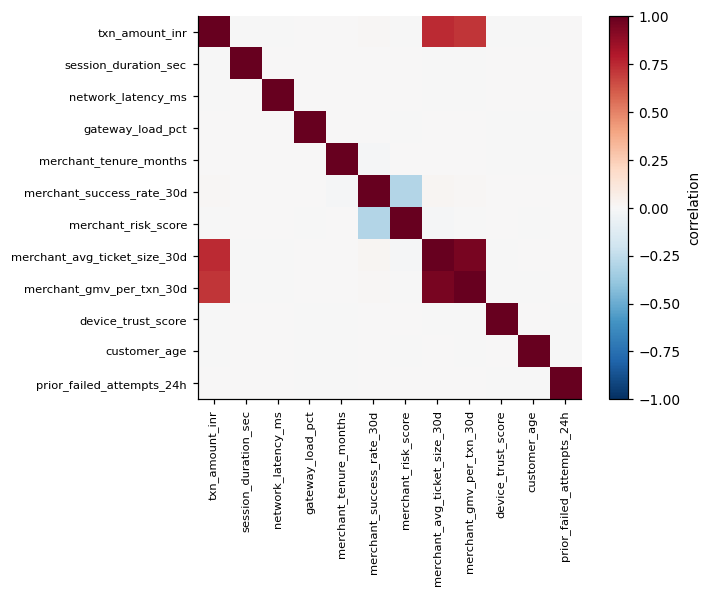

ticket size vs gmv per txn: 0.952


In [13]:
num_cols = ["txn_amount_inr", "session_duration_sec", "network_latency_ms", "gateway_load_pct",
            "merchant_tenure_months", "merchant_success_rate_30d", "merchant_risk_score",
            "merchant_avg_ticket_size_30d", "merchant_gmv_per_txn_30d",
            "device_trust_score", "customer_age", "prior_failed_attempts_24h"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=7.5)
ax.grid(False); plt.colorbar(im, fraction=0.046, label="correlation")
plt.tight_layout(); plt.show()

print("ticket size vs gmv per txn:",
      round(df["merchant_avg_ticket_size_30d"].corr(df["merchant_gmv_per_txn_30d"]), 3))

`merchant_avg_ticket_size_30d` and `merchant_gmv_per_txn_30d` correlate at 0.95. Looking at
the data dictionary they're the same thing, average basket value, calculated two different ways.

The problem this causes isn't the one people usually expect. The predictions come out fine.
It's the coefficients that break: with two near-identical columns, how the shared effect gets
split between them is basically arbitrary, so you can't read either one and say what it means.
Readable coefficients are most of why I'm using logistic regression here, so one of them goes.

For Random Forest and XGBoost this doesn't matter. The two columns just share the splits.
Stripping out correlated features before fitting a Random Forest is a common habit and it's
a linear-model concern only.


In [14]:
df = df.drop(columns=["merchant_gmv_per_txn_30d"])

## 2.4 The plot that changed the project

A correlation only measures a straight-line relationship, so before trusting one I bin the
column and plot the actual failure rate per bin.


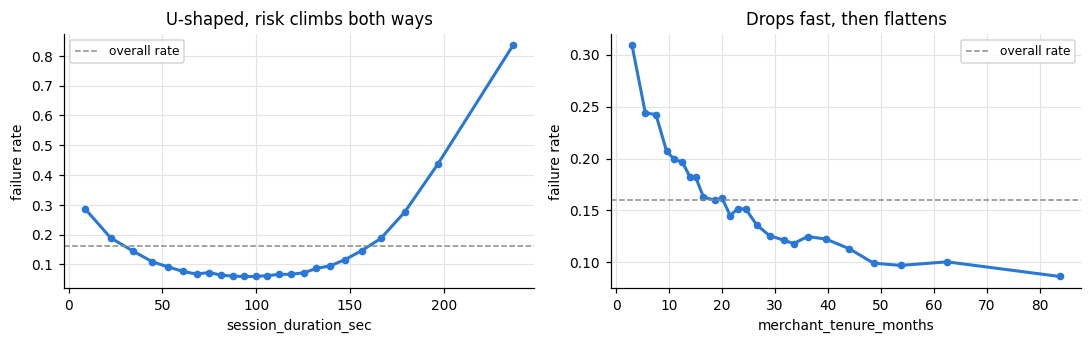

correlation of session_duration with failure: 0.213


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
base = df["payment_failed"].mean()

for ax, col in zip(axes, ["session_duration_sec", "merchant_tenure_months"]):
    bins = pd.qcut(df[col], q=25, duplicates="drop")
    rate = df.groupby(bins, observed=True)["payment_failed"].mean()
    mid = df.groupby(bins, observed=True)[col].mean()
    ax.plot(mid, rate, marker="o", markersize=4, color=BLUE, linewidth=2)
    ax.axhline(base, color=GREY, linestyle="--", linewidth=1, label="overall rate")
    ax.set_xlabel(col); ax.set_ylabel("failure rate"); ax.legend(fontsize=8)

axes[0].set_title("U-shaped, risk climbs both ways")
axes[1].set_title("Drops fast, then flattens")
plt.tight_layout(); plt.show()

print("correlation of session_duration with failure:",
      round(df["session_duration_sec"].corr(df["payment_failed"]), 3))

`session_duration_sec` correlates 0.21 with the target. On a correlation table that reads
as a middling feature you'd probably skip. The plot says otherwise: risk bottoms out around
90 seconds and climbs steeply in both directions. Very fast checkouts look like bots testing
stolen cards, very slow ones run past the bank's OTP timeout.

This is the thing logistic regression can't do. It fits a straight line through each column,
and the best straight line through a U is nearly flat, so the feature contributes almost
nothing. A decision tree just splits twice, under 40 and over 180, and picks it up without
being told.

It's also why logistic regression loses in section 6 and then wins in 6.3.


## 2.5 Two columns that only mean something together

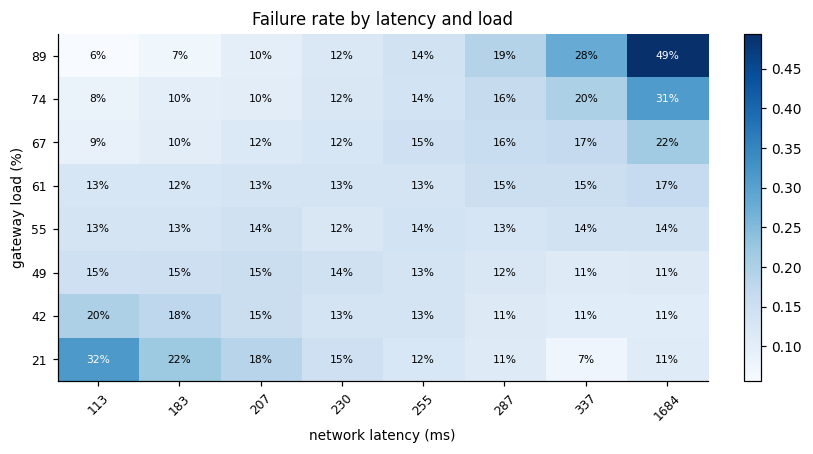

In [16]:
lat_bin  = pd.qcut(df["network_latency_ms"].clip(upper=3000), q=8, duplicates="drop")
load_bin = pd.qcut(df["gateway_load_pct"], q=8, duplicates="drop")
grid = df.groupby([load_bin, lat_bin], observed=True)["payment_failed"].mean().unstack()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(grid.values, cmap="Blues", aspect="auto", origin="lower")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels([f"{i.mid:.0f}" for i in grid.columns], rotation=45, fontsize=8)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels([f"{i.mid:.0f}" for i in grid.index], fontsize=8)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7,
                color="white" if v > grid.values.max() * 0.6 else "black")
ax.set_xlabel("network latency (ms)"); ax.set_ylabel("gateway load (%)")
ax.set_title("Failure rate by latency and load"); ax.grid(False)
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

In [17]:
low  = df[df["gateway_load_pct"] < df["gateway_load_pct"].quantile(0.25)]
high = df[df["gateway_load_pct"] > df["gateway_load_pct"].quantile(0.75)]

for label, part in [("LOW  load", low), ("HIGH load", high)]:
    mid = part["network_latency_ms"].median()
    fast = part[part["network_latency_ms"] < mid]["payment_failed"].mean()
    slow = part[(part["network_latency_ms"] >= mid) & (part["network_latency_ms"] < 5000)]["payment_failed"].mean()
    print(f"{label}:  fast {fast:.3f}  ->  slow {slow:.3f}   ({100*(slow-fast):+.1f} pp)")

LOW  load:  fast 0.225  ->  slow 0.112   (-11.3 pp)
HIGH load:  fast 0.112  ->  slow 0.277   (+16.6 pp)


Read one row of the heatmap at a time. Latency doesn't just matter more as load rises, it
flips direction. At low load slow payments fail less (22.5% down to 11.2%). At high load they
fail much more (11.2% up to 27.7%).

That's why latency on its own is nearly useless as a predictor. The two halves cancel each
other out. It only means anything once you know the load.

I'm not fully sure why the low-load direction goes that way. My guess is a slow response at
low load means the bank is running full 3D Secure checks, which pass, while at high load
slow means queueing, which times out. Worth asking the payments team rather than assuming.

Either way, logistic regression adds its features up, so it can only average the two
opposite effects into something near zero. A tree splits on load first and then on latency
inside that branch. I hand logistic regression a `latency x load` column in 6.3 to even
things up.


## 2.6 Categories

In [18]:
cat_cols = ["payment_method", "merchant_category", "card_network", "device_os",
            "region", "customer_tier", "issuer_bank_code", "experiment_group"]
print(df[cat_cols].nunique().sort_values(ascending=False).to_string())

print("\nfailure rate by payment method:")
print(df.groupby("payment_method")["payment_failed"].mean().sort_values().round(3).to_string())

issuer_bank_code     45
merchant_category    11
region                6
payment_method        6
card_network          5
device_os             4
customer_tier         3
experiment_group      2

failure rate by payment method:
payment_method
UPI            0.125
Wallet         0.141
Credit Card    0.173
Debit Card     0.195
EMI            0.211
Net Banking    0.221


`issuer_bank_code` has 45 levels and most of them are noise, only a handful of banks really
behave differently. One-hot encoding turns that one column into 44.

That's fine for the trees, they ignore the useless ones, and fine for logistic regression
where the L2 penalty shrinks them. KNN is the one that suffers, because it measures distance
between rows and 44 mostly-zero columns pad the distance out without adding anything. I test
that in section 6 rather than just asserting it.


---
# 3. Leakage check

One question per column:

> Would I actually have this value, with this value, at the moment I need to make the prediction?

We score a payment before we route it, so anything recorded during or after the attempt is
out, no matter how good it looks. Three column names looked suspicious.


In [19]:
for col in ["retry_within_10min_flag", "support_ticket_raised", "gateway_error_code"]:
    x = df[col] if pd.api.types.is_numeric_dtype(df[col]) else df[col].notna().astype(int)
    print(f"{col:26s} AUC on its own = {roc_auc_score(df['payment_failed'], x):.3f}")

print("\nbest normal feature, for comparison:")
print(f"{'prior_failed_attempts_24h':26s} AUC on its own = "
      f"{roc_auc_score(df['payment_failed'], df['prior_failed_attempts_24h']):.3f}")

print("\ngateway_error_code is filled in for:")
print(f"  {df.loc[df.payment_failed == 1, 'gateway_error_code'].notna().mean():.0%} of failed payments")
print(f"  {df.loc[df.payment_failed == 0, 'gateway_error_code'].notna().mean():.0%} of successful payments")

retry_within_10min_flag    AUC on its own = 0.923


support_ticket_raised      AUC on its own = 0.700
gateway_error_code         AUC on its own = 0.990

best normal feature, for comparison:


prior_failed_attempts_24h  AUC on its own = 0.641

gateway_error_code is filled in for:
  100% of failed payments
  2% of successful payments


All three are leakage. They get written down *because* of the outcome.

The bank sends an error code because the payment failed. The customer retries after seeing
it fail. A support ticket gets raised hours later. The best legitimate feature manages 0.64,
so a single yes/no column scoring 0.92 isn't a great feature, it's the answer written on the
front of the card.

This is the part I'd defend hardest. Keeping `retry_within_10min_flag` gives you a model
around 0.97 AUC. It looks brilliant, passes review, ships, and then does nothing, because
when we score a live payment nobody has retried yet, so the column is always 0 and the model
says "success" to everything. A model that looks worse on clean columns beats one that looks
great on leaked ones.

I'd also want to ask the payments engineer about `merchant_success_rate_30d`. A rolling
30-day window is fine. If the warehouse recalculates it over the whole period afterwards,
that's leakage too, and I can't tell which from the data alone.


In [20]:
df = df.drop(columns=["gateway_error_code", "retry_within_10min_flag", "support_ticket_raised"])
print("columns left:", df.shape[1])

columns left: 31


---
# 4. A/B test: did `smart_retry` work?

For six months every payment went randomly into one of two groups. Control kept the old
policy, retry with the same bank on a soft decline. Treatment picked the retry bank by its
live success rate.

Decided before looking at anything:

- H0: both groups have the same failure rate
- H1: they're different (two-sided, because I want to catch it getting worse too)
- alpha = 0.05


In [21]:
# Did the split actually come out 50/50?
counts = df["experiment_group"].value_counts().sort_index()
chi2, p = stats.chisquare(counts.values, [len(df)/2, len(df)/2])

print(counts.to_string())
print(f"\nsplit: {counts.iloc[0]/len(df):.2%} / {counts.iloc[1]/len(df):.2%}")
print(f"chi-square = {chi2:.2f}, p = {p:.3f}")
print("fine" if p > 0.01 else "PROBLEM - don't trust anything below this")

experiment_group
control        99772
smart_retry    99578

split: 50.05% / 49.95%
chi-square = 0.19, p = 0.664
fine


This goes first. If the groups aren't the size they should be then the randomiser is
broken somewhere, a bug or a bot filter or a redirect failing on one side, and every number
after it is meaningless. One line, catches a lot.


In [22]:
control = df[df["experiment_group"] == "control"]
treated = df[df["experiment_group"] == "smart_retry"]

x1, n1 = control["payment_failed"].sum(), len(control)
x2, n2 = treated["payment_failed"].sum(), len(treated)
p1, p2 = x1 / n1, x2 / n2

pooled = (x1 + x2) / (n1 + n2)
se = np.sqrt(pooled * (1 - pooled) * (1/n1 + 1/n2))
z = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

# CI uses the unpooled standard error - pooling assumes H0, which is right for the
# test statistic and wrong for the interval
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
diff = p1 - p2
low, high = diff - 1.96*se_diff, diff + 1.96*se_diff

print(f"control     {x1:,} failures / {n1:,} = {p1:.2%}")
print(f"smart_retry {x2:,} failures / {n2:,} = {p2:.2%}")
print("-" * 55)
print(f"difference     : {diff*100:.2f} percentage points")
print(f"95% CI         : [{low*100:.2f}, {high*100:.2f}] pp")
print(f"relative change: {diff/p1:.1%} fewer failures")
print(f"z = {z:.2f},  p = {p_value:.2e}")

control     16,488 failures / 99,772 = 16.53%
smart_retry 15,428 failures / 99,578 = 15.49%
-------------------------------------------------------
difference     : 1.03 percentage points
95% CI         : [0.71, 1.35] pp
relative change: 6.2% fewer failures
z = 6.28,  p = 3.29e-10


Failures went from 16.53% to 15.49%, about a percentage point, or 6% fewer failures.

The interval matters more than the p-value here. p = 3e-10 only says it isn't a fluke. The
interval [0.71, 1.35] says how big the win is, and the whole range clears the 0.5pp bar the
team set, so the decision is easy. A result can be very significant and still too small to
bother with, which is exactly what happens with the guardrail two cells down.

Worth being precise about one thing: the p-value isn't the chance H0 is true. It's the
chance of seeing a gap this big if H0 were true.


In [23]:
# Was the test big enough to find an effect this size?
def sample_size_needed(base_rate, effect, alpha=0.05, power=0.80):
    za = stats.norm.ppf(1 - alpha/2)
    zb = stats.norm.ppf(power)
    return int(np.ceil(2 * base_rate * (1-base_rate) * (za+zb)**2 / effect**2))

za, zb = stats.norm.ppf(0.975), stats.norm.ppf(0.80)
mde = (za + zb) * np.sqrt(2 * p1 * (1-p1) / n2)

print(f"rows per group: {n2:,}")
print(f"smallest effect we could reliably detect: {mde*100:.2f} pp")
print(f"what we actually saw                    : {diff*100:.2f} pp\n")

for effect in [0.0025, 0.005, 0.01, 0.02]:
    print(f"  to detect {effect*100:.2f} pp we'd have needed "
          f"{sample_size_needed(p1, effect):>9,} rows per group")

rows per group: 99,578
smallest effect we could reliably detect: 0.47 pp
what we actually saw                    : 1.03 pp

  to detect 0.25 pp we'd have needed   346,474 rows per group
  to detect 0.50 pp we'd have needed    86,619 rows per group
  to detect 1.00 pp we'd have needed    21,655 rows per group
  to detect 2.00 pp we'd have needed     5,414 rows per group


This is why the test needed 200,000 rows. At 10,000 per group we could only have spotted
about 1.5pp, so a real 0.5pp improvement would have been missed completely. That's a Type II
error, and nobody writes a post-mortem about the win they never noticed, which is why this
calculation belongs before the experiment rather than after it.


In [24]:
avg_loss = df.loc[df["revenue_loss_inr"] > 0, "revenue_loss_inr"].mean()
months = (df["txn_timestamp"].max() - df["txn_timestamp"].min()).days / 30.4
scale = (len(df) / n2) * (12 / months)      # to all traffic, for a full year

print(f"average loss per failed payment: Rs {avg_loss:,.0f}")
print(f"failures avoided during the test: {diff*n2:,.0f}\n")
print("if rolled out to everyone, per year:")
print(f"  {diff*n2*scale:,.0f} failures avoided")
print(f"  Rs {diff*n2*scale*avg_loss:,.0f} recovered")
print(f"  (range Rs {low*n2*scale*avg_loss:,.0f} to Rs {high*n2*scale*avg_loss:,.0f})")

average loss per failed payment: Rs 451
failures avoided during the test: 1,028

if rolled out to everyone, per year:
  4,171 failures avoided
  Rs 1,879,643 recovered
  (range Rs 1,293,498 to Rs 2,465,787)


I'd quote the range, not the single number. One figure claims more precision than the
experiment actually has.


In [25]:
# Guardrail. Smart routing does extra work before routing, so check latency didn't suffer.
clean = df[df["network_latency_ms"] < 5000]     # drop the broken sensor readings from 2.2
a = clean.loc[clean["experiment_group"] == "control", "network_latency_ms"]
b = clean.loc[clean["experiment_group"] == "smart_retry", "network_latency_ms"]

t_stat, p_lat = stats.ttest_ind(a, b, equal_var=False)      # Welch, no equal-variance assumption
cohens_d = (b.mean() - a.mean()) / np.sqrt((a.var() + b.var()) / 2)

print(f"control     mean latency {a.mean():.1f} ms")
print(f"smart_retry mean latency {b.mean():.1f} ms")
print(f"difference  {b.mean()-a.mean():+.1f} ms ({(b.mean()-a.mean())/a.mean():+.1%})")
print(f"\nWelch t-test: p = {p_lat:.1e}")
print(f"Cohen's d   : {cohens_d:.3f}")

control     mean latency 249.5 ms
smart_retry mean latency 255.6 ms
difference  +6.1 ms (+2.4%)

Welch t-test: p = 6.2e-57
Cohen's d   : 0.073


Best example in the notebook of significant not meaning important.

p is 1e-57, which sounds overwhelming. The actual difference is 6ms on a 250ms baseline, and
Cohen's d is 0.07, well under the 0.2 that counts as a "small" effect. With 190,000 rows the
test can pick up differences nobody could possibly notice. The bigger your sample, the
smaller the difference a test will flag, so at this size the effect size does the deciding
and the p-value is close to a formality.

6ms to stop 1% of payments failing is an easy trade. Guardrail passes.


In [26]:
# Did it work equally well for every payment method?
rows = []
for method, part in df.groupby("payment_method"):
    t = part.groupby("experiment_group")["payment_failed"].agg(["sum", "count"])
    c, nc = t.loc["control"]
    s, ns = t.loc["smart_retry"]
    pool = (c + s) / (nc + ns)
    zz = (c/nc - s/ns) / np.sqrt(pool * (1-pool) * (1/nc + 1/ns))
    rows.append({"payment_method": method, "n": nc + ns,
                 "lift_pp": round(100 * (c/nc - s/ns), 2),
                 "p_value": round(2 * (1 - stats.norm.cdf(abs(zz))), 4)})

segments = pd.DataFrame(rows).sort_values("lift_pp", ascending=False)
segments["passes_alpha_0.05"] = segments["p_value"] < 0.05
segments["passes_bonferroni"] = segments["p_value"] < 0.05 / len(segments)
segments

,payment_method,n,lift_pp,p_value,passes_alpha_0.05,passes_bonferroni
4,UPI,83450,1.62,0.0000,True,True
1,Debit Card,31722,1.09,0.0141,True,False
2,EMI,7914,0.76,0.4103,False,False
3,Net Banking,21836,0.44,0.4344,False,False
0,Credit Card,36410,0.40,0.3121,False,False
5,Wallet,18018,0.20,0.6972,False,False


UPI is where the win comes from, 1.6pp, and that makes sense: UPI has the most banks to
route between so choosing a better one has the most to work with.

Debit Card is the trap. p = 0.014 reads as significant. But I ran 6 tests, and with 6 tests
at alpha 0.05 the chance of at least one false positive is 1 - 0.95^6, about 26%. The
Bonferroni threshold is 0.05/6 = 0.0083 and 0.014 doesn't clear it.

So: ship it to everyone, the overall result is solid and the guardrail passed. But "it also
helps debit cards" is something to test next, not something we found. A segment you name in
advance is a result, one you spot afterwards is a hypothesis.


---
# 5. Setting up the models

## 5.1 Split first


In [27]:
X = df.drop(columns=["txn_id", "merchant_id", "txn_timestamp",
                     "revenue_loss_inr", "payment_failed"])
y = df["payment_failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("train:", X_train.shape, " test:", X_test.shape)
print(f"failure rate - train {y_train.mean():.3f}, test {y_test.mean():.3f}")

train: (159480, 26)  test: (39870, 26)
failure rate - train 0.160, test 0.160


`stratify=y` keeps the 16% rate the same in both halves, so the test score isn't partly
measuring a difference in base rate.

This is a random split. For a model that scores future payments a time-based split, train on
months 1-4 and test on 5-6, is the more honest test because it catches drift too. The monthly
failure rate here is flat so I'd expect them to agree, but I've put it on the checklist at
the end rather than pretending it doesn't matter.


## 5.2 Two recipes, not one

Different models need different prep. Using one recipe for everything is the easiest way to
quietly cripple half your comparison.

| Step | Logistic / KNN | Trees (DT, RF, XGBoost) |
|---|---|---|
| Fill missing values | yes | yes (sklearn needs it) |
| Scale | yes | pointless |
| Cap extreme values | yes | pointless |
| One-hot encode | yes | yes |

KNN measures distance between rows. Unscaled, latency runs into the thousands while
`prior_failed_attempts_24h` runs 0 to 5, so the distance is basically "difference in
milliseconds" and everything else is rounding error.

A tree asks "is this column above 400?". Rescaling just changes 400 to some other number and
the same rows land on the same side.


In [28]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

def cap_extremes(data):
    data = data.copy()
    data["network_latency_ms"] = data["network_latency_ms"].clip(upper=3000)   # gateway timeout
    # percentile cap, learned on train only
    data["txn_amount_inr"] = data["txn_amount_inr"].clip(upper=X_train["txn_amount_inr"].quantile(0.99))
    return data

X_train_capped = cap_extremes(X_train)
X_test_capped = cap_extremes(X_test)

# Recipe A: fill, scale, one-hot   (logistic regression, KNN)
preprocess_scaled = ColumnTransformer([
    ("num", Pipeline([("fill", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

# Recipe B: fill, one-hot, no scaling   (trees)
preprocess_trees = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

print(len(num_cols), "numeric +", len(cat_cols), "categorical columns")

18 numeric + 8 categorical columns


Note the latency cap is a fixed 3,000 rather than a percentile. The 99th percentile would
land inside the broken readings, since they're 4% of the data, and cut almost nothing. A
percentile cap only works if you already know the junk is smaller than the tail you're
cutting. The gateway's timeout is a real physical ceiling so it doesn't need to be learned
from the data at all.


---
# 6. Training

## 6.1 First round, no feature engineering


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=100,
                                            class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                            class_weight="balanced", n_jobs=-1, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                                 subsample=0.8, colsample_bytree=0.8,
                                 scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                                 eval_metric="aucpr", n_jobs=-1, random_state=SEED),
}

needs_scaling = ["Logistic Regression"]     # KNN is done separately below

results = []
fitted = {}

for name, model in models.items():
    if name in needs_scaling:
        prep, xtr, xte = preprocess_scaled, X_train_capped, X_test_capped
    else:
        prep, xtr, xte = preprocess_trees, X_train, X_test

    pipe = Pipeline([("prep", prep), ("model", model)])
    pipe.fit(xtr, y_train)

    proba = pipe.predict_proba(xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    train_auc = roc_auc_score(y_train, pipe.predict_proba(xtr)[:, 1])

    fitted[name] = (pipe, xte)
    results.append({
        "model": name,
        "ROC_AUC": round(roc_auc_score(y_test, proba), 4),
        "PR_AUC": round(average_precision_score(y_test, proba), 4),
        "precision": round(precision_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "f1": round(f1_score(y_test, pred), 3),
        "train_minus_test_AUC": round(train_auc - roc_auc_score(y_test, proba), 4),
    })
    print(f"{name:22s} ROC-AUC {results[-1]['ROC_AUC']:.4f}   PR-AUC {results[-1]['PR_AUC']:.4f}")

Logistic Regression    ROC-AUC 0.8196   PR-AUC 0.5329


Decision Tree          ROC-AUC 0.8810   PR-AUC 0.6598


Random Forest          ROC-AUC 0.9127   PR-AUC 0.7167


XGBoost                ROC-AUC 0.9324   PR-AUC 0.7857


In [30]:
# What happens without a depth limit
runaway = Pipeline([("prep", preprocess_trees), ("model", DecisionTreeClassifier(random_state=SEED))])
runaway.fit(X_train, y_train)
print(f"train AUC {roc_auc_score(y_train, runaway.predict_proba(X_train)[:,1]):.4f}")
print(f"test  AUC {roc_auc_score(y_test, runaway.predict_proba(X_test)[:,1]):.4f}")

train AUC 1.0000
test  AUC 0.7224


Perfect on data it's seen, mediocre on data it hasn't. That's overfitting in one cell, and
it's why `max_depth` and `min_samples_leaf` are set on the tree above. Random Forest solves
the same problem a different way, by growing lots of deep trees and averaging them so the
individual overfits cancel.


## 6.2 KNN

KNN has no training step, it stores every row and measures distances at prediction time.
That makes it slow, cost grows with training rows times test rows, so I run it on 30,000
rows. Not laziness, and it's itself a reason KNN is a bad fit for a gateway scoring thousands
of payments a second.


In [31]:
sample = X_train_capped.sample(30_000, random_state=SEED)
y_sample = y_train.loc[sample.index]
test_sample = X_test_capped.sample(20_000, random_state=SEED)
y_test_sample = y_test.loc[test_sample.index]

knn = Pipeline([("prep", preprocess_scaled), ("model", KNeighborsClassifier(n_neighbors=35, n_jobs=-1))])
knn.fit(sample, y_sample)
knn_proba = knn.predict_proba(test_sample)[:, 1]
knn_pred = (knn_proba >= 0.5).astype(int)

results.append({
    "model": "KNN (k=35)",
    "ROC_AUC": round(roc_auc_score(y_test_sample, knn_proba), 4),
    "PR_AUC": round(average_precision_score(y_test_sample, knn_proba), 4),
    "precision": round(precision_score(y_test_sample, knn_pred), 3),
    "recall": round(recall_score(y_test_sample, knn_pred), 3),
    "f1": round(f1_score(y_test_sample, knn_pred), 3),
    "train_minus_test_AUC": np.nan,
})
print("KNN with scaling, ROC-AUC:", results[-1]["ROC_AUC"])

KNN with scaling, ROC-AUC: 0.8413


In [32]:
# Same thing without scaling
no_scaling = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])
knn_bad = Pipeline([("prep", no_scaling), ("model", KNeighborsClassifier(n_neighbors=35, n_jobs=-1))])
knn_bad.fit(sample, y_sample)

print("with scaling   :", results[-1]["ROC_AUC"])
print("without scaling:", round(roc_auc_score(y_test_sample, knn_bad.predict_proba(test_sample)[:,1]), 4))

with scaling   : 0.8413


without scaling: 0.6878


Forgetting to scale costs about 0.15 AUC and nothing warns you. No error, no message. The
model just answers a different question and you never find out why it did badly.

One other thing in the table below: KNN's recall is 0.10 despite a decent 0.84 AUC. With
k=35 and a 16% failure rate a payment needs 18 of its 35 neighbours to be failures before it
scores above 0.5, which basically never happens. `KNeighborsClassifier` has no `class_weight`,
so the fix is a much lower cutoff. Same lesson as 7.2, arriving early.


In [33]:
pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

,model,ROC_AUC,PR_AUC,precision,recall,f1,train_minus_test_AUC
0,XGBoost,0.9324,0.7857,0.557,0.832,0.667,0.0321
1,Random Forest,0.9127,0.7167,0.518,0.794,0.627,0.0434
2,Decision Tree,0.8810,0.6598,0.460,0.770,0.576,0.0085
3,KNN (k=35),0.8413,0.5400,0.810,0.102,0.181,NaN
4,Logistic Regression,0.8196,0.5329,0.363,0.738,0.486,0.0008


XGBoost beats logistic regression by about 0.11 AUC. The easy read is "trees are better on
tabular data, ship XGBoost". It points at a decent model but it's the wrong lesson, and the
same reasoning would mislead me on the next dataset.

The useful question is why. Trees and linear models differ in one relevant way: trees handle
curves and combinations of columns without being told, linear models can't. And I already
found one of each back in 2.4 and 2.5.

So the gap isn't proof logistic regression is weak. It's proof I handed it the features in
the wrong shape.


## 6.3 Fixing the features

Three new columns, each one a straight translation of something from the EDA. No new
information in any of them, they're all built from columns the model already had.


In [34]:
def add_features(data):
    data = data.copy()
    # distance from the 90 second sweet spot, squared, so a straight line can bend
    data["session_squared"] = ((data["session_duration_sec"] - 90) / 60).clip(-1.5, 2.6) ** 2
    # latency times load, so the effect of one can depend on the other
    lat = ((data["network_latency_ms"] - 250) / 110).clip(-1.8, 3.0)
    load = ((data["gateway_load_pct"] - 55) / 26).clip(-1.9, 1.9)
    data["latency_x_load"] = lat * load
    data["log_tenure"] = np.log1p(data["merchant_tenure_months"])
    return data

X_train_eng = add_features(X_train_capped)
X_test_eng = add_features(X_test_capped)
new_cols = ["session_squared", "latency_x_load", "log_tenure"]

preprocess_eng = ColumnTransformer([
    ("num", Pipeline([("fill", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols + new_cols),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

logit_v2 = Pipeline([("prep", preprocess_eng),
                     ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                                  random_state=SEED))])
logit_v2.fit(X_train_eng, y_train)

proba_v2 = logit_v2.predict_proba(X_test_eng)[:, 1]
pred_v2 = (proba_v2 >= 0.5).astype(int)
fitted["Logistic Regression (fixed)"] = (logit_v2, X_test_eng)

results.append({
    "model": "Logistic Regression (fixed)",
    "ROC_AUC": round(roc_auc_score(y_test, proba_v2), 4),
    "PR_AUC": round(average_precision_score(y_test, proba_v2), 4),
    "precision": round(precision_score(y_test, pred_v2), 3),
    "recall": round(recall_score(y_test, pred_v2), 3),
    "f1": round(f1_score(y_test, pred_v2), 3),
    "train_minus_test_AUC": round(roc_auc_score(y_train, logit_v2.predict_proba(X_train_eng)[:,1])
                                  - roc_auc_score(y_test, proba_v2), 4),
})

pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

,model,ROC_AUC,PR_AUC,precision,recall,f1,train_minus_test_AUC
0,XGBoost,0.9324,0.7857,0.557,0.832,0.667,0.0321
1,Logistic Regression (fixed),0.9285,0.7737,0.524,0.849,0.648,0.0020
2,Random Forest,0.9127,0.7167,0.518,0.794,0.627,0.0434
3,Decision Tree,0.8810,0.6598,0.460,0.770,0.576,0.0085
4,KNN (k=35),0.8413,0.5400,0.810,0.102,0.181,NaN
5,Logistic Regression,0.8196,0.5329,0.363,0.738,0.486,0.0008


Logistic regression goes from 0.82 to 0.93 and moves from last to second, off three columns
that contain no new information.

That's the real lesson and it's worth stating carefully. "Trees beat linear models on tabular
data" is a statement about default features, not about what the models can represent.
Logistic regression is a straight line *in the features you give it*, and any function of
your features is still a feature. The trees' advantage was finding the U-shape and the
interaction on their own.

The honest caveat: I found those two because I went looking, and I already suspected they
were there. On a dataset with fifty columns and a dozen interactions that search doesn't
scale, and XGBoost finding them automatically is worth real money. So the way to read the
gap that's left is as a measure of how much structure I haven't encoded yet.


---
# 7. Evaluation

## 7.1 Curves


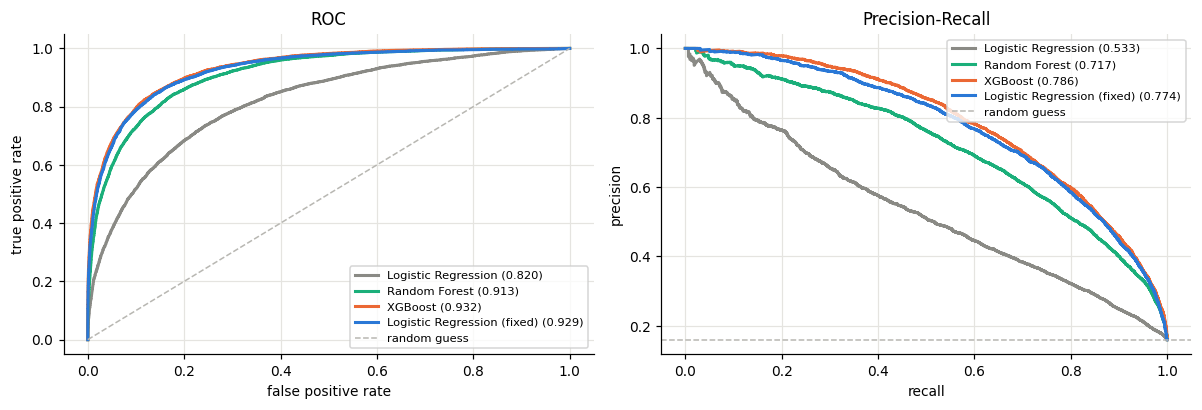

In [35]:
show = ["Logistic Regression", "Random Forest", "XGBoost", "Logistic Regression (fixed)"]
colors = {"Logistic Regression": GREY, "Random Forest": "#1baf7a",
          "XGBoost": ORANGE, "Logistic Regression (fixed)": BLUE}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name in show:
    pipe, xte = fitted[name]
    p = pipe.predict_proba(xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=colors[name], linewidth=2,
                 label=f"{name} ({roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, color=colors[name], linewidth=2,
                 label=f"{name} ({average_precision_score(y_test, p):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="#b8b7b2", linewidth=1, label="random guess")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC"); axes[0].legend(fontsize=7.5, loc="lower right")

axes[1].axhline(y_test.mean(), color="#b8b7b2", linestyle="--", linewidth=1, label="random guess")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall"); axes[1].legend(fontsize=7.5, loc="upper right")
plt.tight_layout(); plt.show()

Both, because they answer different questions. ROC uses the true negative rate and with 84%
negatives that denominator is huge, so ROC-AUC looks generous and moves slowly. The PR curve
ignores true negatives and answers what operations actually asks: if we act on the riskiest
X%, how many of those really do fail? The models are spread much further apart on the right
hand chart.


## 7.2 Picking the cutoff

`predict()` uses 0.5 because that's the default, not because it's right. The right cutoff
comes from the costs at the top: ₹450 for a miss, ₹30 for a false alarm.


In [36]:
COST_MISS, COST_FALSE_ALARM = 450, 30

rows = []
for t in np.arange(0.05, 0.96, 0.01):
    pred = (proba_v2 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({"threshold": round(t, 2),
                 "caught": tp, "false_alarms": fp, "missed": fn,
                 "precision": round(tp/(tp+fp), 3), "recall": round(tp/(tp+fn), 3),
                 "f1": round(f1_score(y_test, pred), 3),
                 "total_cost": COST_MISS*fn + COST_FALSE_ALARM*fp})

costs = pd.DataFrame(rows)
best_t = costs.loc[costs["total_cost"].idxmin(), "threshold"]

print(f"cheapest cutoff     : {best_t:.2f}")
print(f"best F1 cutoff      : {costs.loc[costs['f1'].idxmax(), 'threshold']:.2f}")
print(f"default             : 0.50\n")
print(costs[costs["threshold"].isin([0.10, 0.20, best_t, 0.40, 0.50, 0.70])].to_string(index=False))

cheapest cutoff     : 0.27
best F1 cutoff      : 0.70
default             : 0.50

 threshold  caught  false_alarms  missed  precision  recall    f1  total_cost
      0.10    6260         16962     123      0.270   0.981 0.423      564210
      0.20    6105         11820     278      0.341   0.956 0.502      479700
      0.27    5982          9573     401      0.385   0.937 0.545      467640
      0.40    5680          6610     703      0.462   0.890 0.608      514650
      0.50    5420          4925     963      0.524   0.849 0.648      581100
      0.70    4702          2429    1681      0.659   0.737 0.696      829320


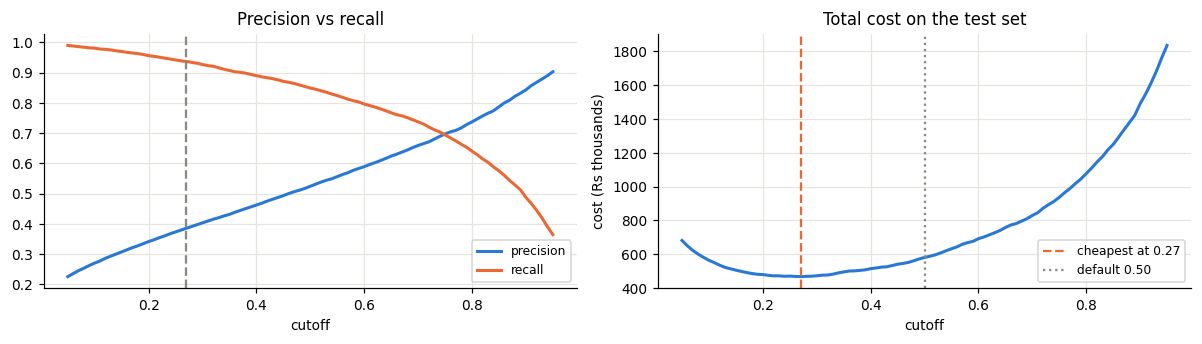

cost at 0.50 : Rs 581,100
cost at 0.27 : Rs 467,640
saved by moving the cutoff: Rs 113,460 (20%)


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(costs["threshold"], costs["precision"], color=BLUE, linewidth=2, label="precision")
ax[0].plot(costs["threshold"], costs["recall"], color=ORANGE, linewidth=2, label="recall")
ax[0].axvline(best_t, color=GREY, linestyle="--")
ax[0].set_xlabel("cutoff"); ax[0].set_title("Precision vs recall"); ax[0].legend(fontsize=8)

ax[1].plot(costs["threshold"], costs["total_cost"] / 1000, color=BLUE, linewidth=2)
ax[1].axvline(best_t, color=ORANGE, linestyle="--", label=f"cheapest at {best_t:.2f}")
ax[1].axvline(0.5, color=GREY, linestyle=":", label="default 0.50")
ax[1].set_xlabel("cutoff"); ax[1].set_ylabel("cost (Rs thousands)")
ax[1].set_title("Total cost on the test set"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

at_default = costs.loc[costs["threshold"] == 0.50, "total_cost"].iloc[0]
at_best = costs["total_cost"].min()
print(f"cost at 0.50 : Rs {at_default:,}")
print(f"cost at {best_t:.2f} : Rs {at_best:,}")
print(f"saved by moving the cutoff: Rs {at_default - at_best:,} ({(at_default-at_best)/at_default:.0%})")

A miss costs 15x a false alarm so the best cutoff sits well below 0.5. It's worth checking
several payments unnecessarily to save one sale.

Moving it changes nothing about the model and costs nothing, and it's worth about 19% of the
total. That's why "the model's done, now pick a cutoff" is a real step rather than an
afterthought.

The best-F1 cutoff is completely different, at 0.70. F1 assumes precision and recall matter
equally and here they differ by 15x, so optimising F1 would be optimising the wrong thing.


In [38]:
final_pred = (proba_v2 >= best_t).astype(int)
print(f"at cutoff {best_t:.2f}:\n")
print(pd.DataFrame(confusion_matrix(y_test, final_pred),
                   index=["really fine", "really failed"],
                   columns=["said fine", "said risky"]).to_string())
print()
print(classification_report(y_test, final_pred, target_names=["success", "failure"], digits=3))

at cutoff 0.27:

               said fine  said risky
really fine        23914        9573
really failed        401        5982

              precision    recall  f1-score   support

     success      0.984     0.714     0.827     33487
     failure      0.385     0.937     0.545      6383

    accuracy                          0.750     39870
   macro avg      0.684     0.826     0.686     39870
weighted avg      0.888     0.750     0.782     39870



## 7.3 What it learned

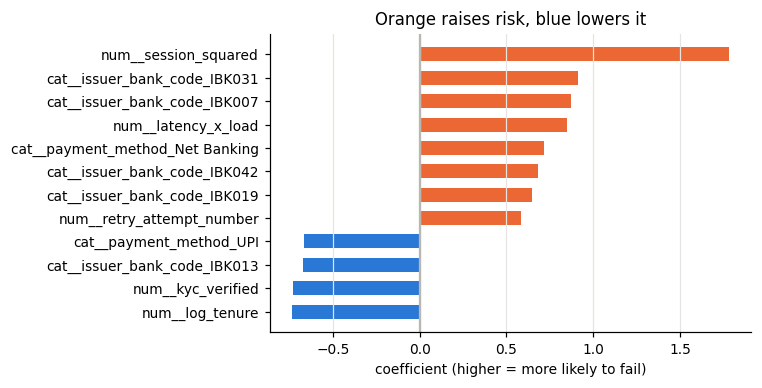

In [39]:
names = logit_v2.named_steps["prep"].get_feature_names_out()
coefs = logit_v2.named_steps["model"].coef_[0]

top = (pd.DataFrame({"feature": names, "coefficient": coefs})
         .assign(size=lambda d: d["coefficient"].abs())
         .sort_values("size", ascending=False).head(12))

fig, ax = plt.subplots(figsize=(7, 3.6))
t = top.sort_values("coefficient")
ax.barh(t["feature"], t["coefficient"],
        color=[ORANGE if c > 0 else BLUE for c in t["coefficient"]], height=0.6)
ax.axvline(0, color="#b8b7b2")
ax.set_xlabel("coefficient (higher = more likely to fail)")
ax.set_title("Orange raises risk, blue lowers it")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

`session_squared` is the biggest driver, which is what the plot in 2.4 predicted. Good sign
that the story holds together.

One caution on reading this. Several `issuer_bank_code` columns have big coefficients, but
each of those banks is about 2% of traffic, so a big effect on 2% of rows barely moves the
overall result. A large coefficient isn't the same as a large contribution. Read these for
direction, not importance.

And it's all correlation. "Payments far from 90 seconds fail more" doesn't mean forcing
90 second checkouts would help. The only causal claim in this notebook is the A/B test, and
only about the one thing it randomised.


---
# 8. What I'd ship

Logistic regression with the three added features, cutoff around 0.27.

XGBoost is more accurate, by about 0.004 ROC-AUC. I'm giving that up deliberately:

- It's one multiplication per feature. The gateway scores payments while the customer waits.
- When risk asks why a payment got flagged I can point at a coefficient. XGBoost needs SHAP
  to answer the same question.
- Train minus test AUC is 0.002 against 0.032 for XGBoost, so there's almost nothing left in
  it to memorise.

I'd keep XGBoost trained alongside anyway. If its lead ever grows that's a free signal that
something new has shown up in the data which my three hand-built columns don't capture.

## Before trusting this in production

1. Confirm the leaky columns with the payments engineer. I dropped three based on reasoning
   about when they get written and someone who knows the system should check that. Same
   question for `merchant_success_rate_30d`, is it a rolling window or recalculated later?
2. Re-test on a time split, train on months 1-4 and test on 5-6. A random split can't catch
   drift and the real model runs on the future.
3. Run it silently for two weeks. Score live payments, act on nothing, check the predictions
   look like the offline ones. A gap means a feature is being calculated differently live
   than in the warehouse, which is the most common way a good model fails and offline testing
   never catches it.
4. Check it works for small merchants, not just on average. They're the ones who can least
   afford a failed payment.
5. Recalculate the cutoff every few months. 0.27 comes from ₹450 and ₹30 and those change.
6. Watch for the feedback loop. Once we start rerouting risky payments they stop failing, so
   next year's training data no longer has the failures we prevented and the model slowly
   forgets what made it useful. Fix is to leave 1-2% of traffic on the old routing so we keep
   getting honest labels.

## What this doesn't prove

The A/B result is causal only for the smart retry change, at a 50/50 split, over these six
months. The model predicts, it doesn't explain, so nothing here is a lever to pull. And
randomisation was per payment, so several payments from the same merchant aren't really
independent, which means the true confidence interval is a bit wider than the one I worked out.
